# Session - 13

# Advanced Data Cleaning & Missing Value Engineering with Pandas

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

# Task 1: The Data Quality Sentinel (Missing Value Visualization)

In [4]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/healthexp.csv"

df = pd.read_csv(url)

df.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


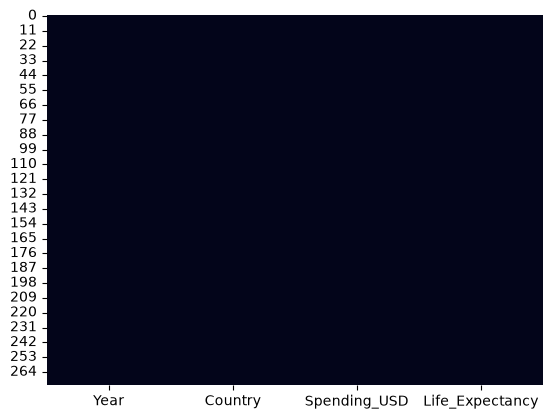

In [7]:
sns.heatmap(df.isna(),cbar=False)
plt.show()

In [8]:
df.isna().sum()

Year               0
Country            0
Spending_USD       0
Life_Expectancy    0
dtype: int64

In [9]:
(df.isna().sum()/len(df)*100).sort_values(ascending=False)

Year               0.0
Country            0.0
Spending_USD       0.0
Life_Expectancy    0.0
dtype: float64

# Analysis

There are no missing values in any column of the Healthcare dataset. Therefore, no column has a higher missing-value concentration than another.

Since the dataset contains no missing values, there is no random or patterned missingness to identify.

Visual inspection using a heatmap is useful because it shows the location and structure of missing values across rows and columns. Raw counts only tell us how many values are missing, while a heatmap can reveal whether missing values are clustered or follow a pattern.

# Task 2: The Integrity Examiner (isna() & notna())

In [10]:
# 1. Count missing values per column
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
})

print("Missing Value Summary:")
print(missing_summary)


# 2. Extract rows where Age is missing
if "Age" in df.columns:
    age_missing = df[df["Age"].isna()]
    print("\nRows where Age is missing:")
    print(age_missing)
else:
    print("\nAge column does not exist in the supplied healthexp.csv")


# 3. Extract rows where Treatment_Cost is NOT missing
if "Treatment_Cost" in df.columns:
    treatment_cost_present = df[df["Treatment_Cost"].notna()]
    print("\nRows where Treatment_Cost is NOT missing:")
    print(treatment_cost_present)
else:
    print("\nTreatment_Cost column does not exist in the supplied healthexp.csv")

Missing Value Summary:
                 Missing_Count  Missing_Percentage
Year                         0                 0.0
Country                      0                 0.0
Spending_USD                 0                 0.0
Life_Expectancy              0                 0.0

Age column does not exist in the supplied healthexp.csv

Treatment_Cost column does not exist in the supplied healthexp.csv


# Business Risks of Ignoring Null Values

Ignoring missing values can lead to inaccurate analysis and unreliable business decisions. Missing data may cause incorrect calculations, biased results, and poor predictions. In healthcare, incomplete patient information can also affect reporting, analysis, and decision-making. Therefore, missing values should be identified and handled appropriately before analysis.

# Task 3: The Structural Pruner (dropna() Strategies)

In [ ]:
# Drop rows where all values are null

df = df.dropna(how="all")

In [6]:
# Drop rows having less than 3 non-null values using thresh

df = df.dropna(thresh=3)

In [7]:
# Drop columns that contain more than 40% missing values

df = df.dropna(axis=1, thresh=len(df)*0.6)

# Trade-offs Between Row Deletion and Column Deletion:

Row deletion removes individual records that contain too many missing values. It helps maintain the useful columns and their information, but deleting too many rows can reduce the dataset size and may result in loss of useful information.
Column deletion removes entire columns that have a high percentage of missing values. It can simplify the dataset and avoid unreliable variables, but it may remove an important feature that could be useful for analysis.
Therefore, row deletion is useful when only a small number of records have insufficient information, while column deletion is useful when a variable contains too many missing values to be reliable.

# Task 4: The Statistical Restorer (Mean / Median / Mode Imputation)

In [9]:
import numpy as np

In [10]:
employee_df = pd.DataFrame({
    "Salary": [45000, 55000, np.nan, 72000, 68000, np.nan],
    "Experience_Years": [1, 3, 5, np.nan, 7, 4],
    "Department": [
        "HR",
        "IT",
        "HR",
        np.nan,
        "Finance",
        "HR"
    ]
})

print("\nOriginal Employee Data:")
print(employee_df)


Original Employee Data:
    Salary  Experience_Years Department
0  45000.0               1.0         HR
1  55000.0               3.0         IT
2      NaN               5.0         HR
3  72000.0               NaN        NaN
4  68000.0               7.0    Finance
5      NaN               4.0         HR


In [11]:
# Salary -> Median
employee_df["Salary"] = employee_df["Salary"].fillna(
    employee_df["Salary"].median()
)


# Experience_Years -> Mean
employee_df["Experience_Years"] = employee_df[
    "Experience_Years"
].fillna(
    employee_df["Experience_Years"].mean()
)


# Department -> Mode
employee_df["Department"] = employee_df["Department"].fillna(
    employee_df["Department"].mode()[0]
)

print("\nAfter Imputation:")
print(employee_df)


After Imputation:
    Salary  Experience_Years Department
0  45000.0               1.0         HR
1  55000.0               3.0         IT
2  61500.0               5.0         HR
3  72000.0               4.0         HR
4  68000.0               7.0    Finance
5  61500.0               4.0         HR


# NOTE:

The given healthcare dataset does not contain the columns Salary, Experience_Years, or Department. Therefore, an imaginary employee dataset was created to demonstrate the required imputation techniques.

For this example:
- Missing Salary values were replaced using the median.
- Missing Experience_Years values were replaced using the mean.
- Missing Department values were replaced using the mode.

# Task 5: The Time-Series Healer (Forward & Backward Fill)

In [12]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

airline_df = pd.read_csv(url)

print(airline_df.head())

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [13]:
airline_df["Month"] = pd.to_datetime(airline_df["Month"])

airline_df = airline_df.set_index("Month")

print(airline_df.head())

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


In [14]:
airline_missing = airline_df.copy()

airline_missing.iloc[2:5,0] = np.nan
airline_missing.iloc[8:10,0] = np.nan

print(airline_missing.head(12))

            Passengers
Month                 
1949-01-01       112.0
1949-02-01       118.0
1949-03-01         NaN
1949-04-01         NaN
1949-05-01         NaN
1949-06-01       135.0
1949-07-01       148.0
1949-08-01       148.0
1949-09-01         NaN
1949-10-01         NaN
1949-11-01       104.0
1949-12-01       118.0


In [15]:
airline_ffill = airline_missing.copy()

airline_ffill["Passengers"] = airline_ffill["Passengers"].ffill()

print("Forward Fill:")
print(airline_ffill.head(12))

Forward Fill:
            Passengers
Month                 
1949-01-01       112.0
1949-02-01       118.0
1949-03-01       118.0
1949-04-01       118.0
1949-05-01       118.0
1949-06-01       135.0
1949-07-01       148.0
1949-08-01       148.0
1949-09-01       148.0
1949-10-01       148.0
1949-11-01       104.0
1949-12-01       118.0


In [16]:
airline_bfill = airline_missing.copy()

airline_bfill["Passengers"] = airline_bfill["Passengers"].bfill()

print("Backward Fill:")
print(airline_bfill.head(12))

Backward Fill:
            Passengers
Month                 
1949-01-01       112.0
1949-02-01       118.0
1949-03-01       135.0
1949-04-01       135.0
1949-05-01       135.0
1949-06-01       135.0
1949-07-01       148.0
1949-08-01       148.0
1949-09-01       104.0
1949-10-01       104.0
1949-11-01       104.0
1949-12-01       118.0


In [17]:
comparison = pd.DataFrame({"Original":airline_missing["Passengers"],
                           "Forward_Fill":airline_ffill["Passengers"],
                           "Backward_Fill":airline_bfill["Passengers"]})

print(comparison.head(12))

            Original  Forward_Fill  Backward_Fill
Month                                            
1949-01-01     112.0         112.0          112.0
1949-02-01     118.0         118.0          118.0
1949-03-01       NaN         118.0          135.0
1949-04-01       NaN         118.0          135.0
1949-05-01       NaN         118.0          135.0
1949-06-01     135.0         135.0          135.0
1949-07-01     148.0         148.0          148.0
1949-08-01     148.0         148.0          148.0
1949-09-01       NaN         148.0          104.0
1949-10-01       NaN         148.0          104.0
1949-11-01     104.0         104.0          104.0
1949-12-01     118.0         118.0          118.0


# Comparison of Forward Fill and Backward Fill

Forward fill (ffill) replaces a missing value with the previous available value. It is useful when the previous observation is a reasonable representation of the missing value.

Backward fill (bfill) replaces a missing value with the next available value. It is useful when the following observation is more appropriate for filling the missing value.

The two methods can produce different results because they use different time points to fill the missing values.

# Why Time Order Is Critical

Time order is important in time-series data because observations are arranged chronologically. Forward fill depends on the previous observation, while backward fill depends on the next observation. If the data is not in the correct chronological order, missing values may be filled using incorrect observations, which can lead to inaccurate analysis.